In [19]:
import pandas as pd
import numpy as np

train = pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s6e2/test.csv')
submission = pd.read_csv("/kaggle/input/playground-series-s6e2/sample_submission.csv")
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [20]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [21]:
print(train["Heart Disease"].value_counts())
print(train["Heart Disease"].unique())

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64
['Presence' 'Absence']


In [22]:
train["Heart Disease"] = (train["Heart Disease"] == "Presence").astype(int)

print(train["Heart Disease"].value_counts())
print(train["Heart Disease"].value_counts(normalize=True).round(3))

Heart Disease
0    347546
1    282454
Name: count, dtype: int64
Heart Disease
0    0.552
1    0.448
Name: proportion, dtype: float64


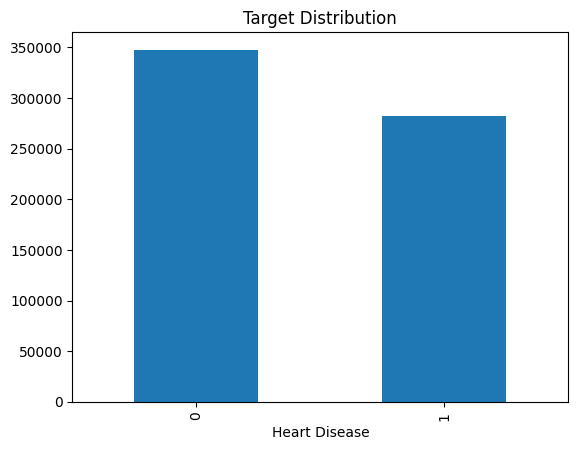

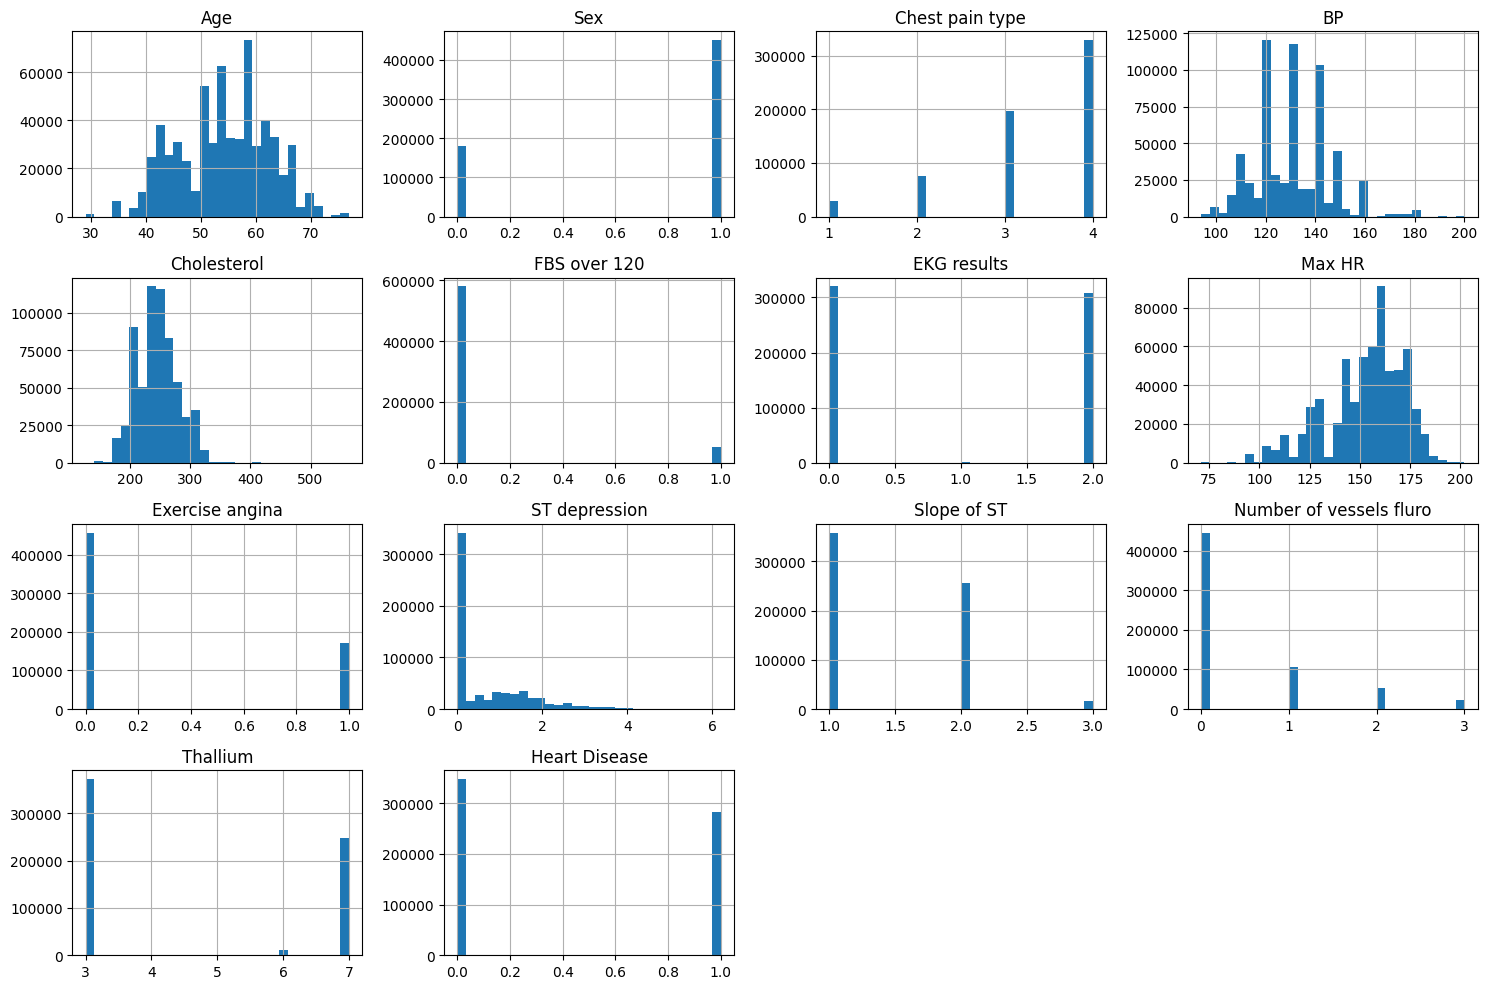

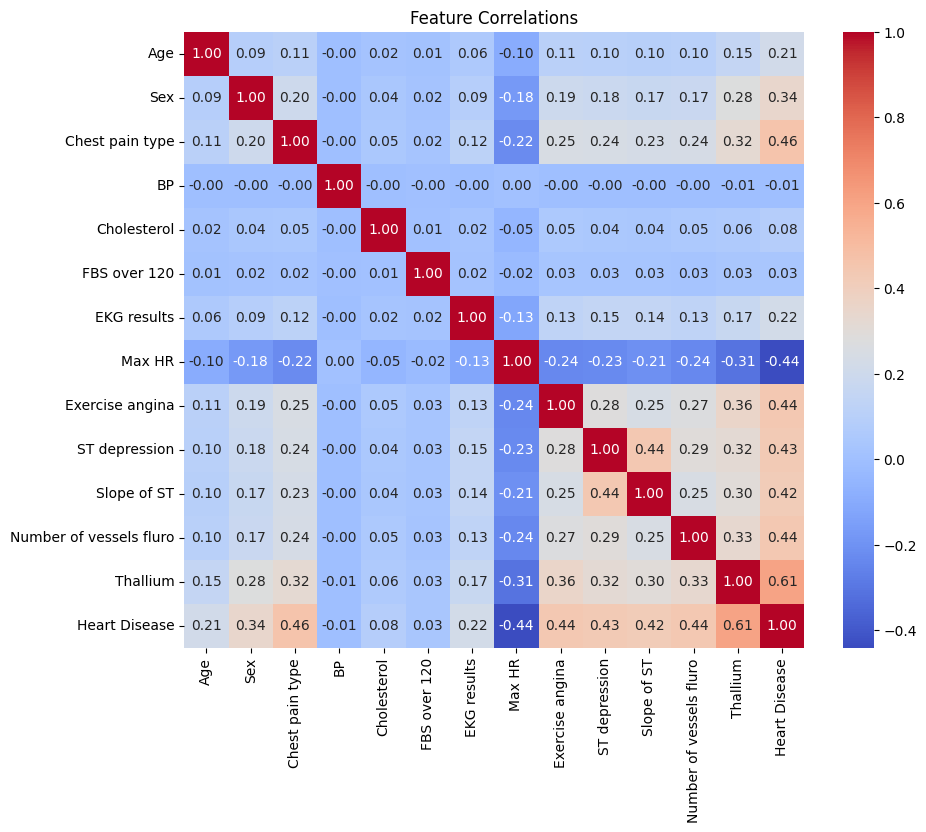

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1 — Target distribution
train["Heart Disease"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.show()

# 2 — Feature distributions by target
X_eda = train.drop(columns=["id"])
X_eda.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

# 3 — Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(X_eda.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()

In [24]:

X = train.drop(columns=["id", "Heart Disease"])
y = train["Heart Disease"]

X_test_final = test.drop(columns=["id"])

print(X.shape)
print(y.shape)
print(X_test_final.shape)
     

(630000, 13)
(630000,)
(270000, 13)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserves 55/45 ratio in both splits
)

print(X_train.shape)
print(X_val.shape)
print(y_train.mean().round(3))
print(y_val.mean().round(3))

(504000, 13)
(126000, 13)
0.448
0.448


In [27]:

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import time

all_results = []

def evaluate_model(name, model, X_val, y_val, train_time):
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    result = {
        "Model"        : name,
        "Accuracy"     : round(accuracy_score(y_val, y_pred), 4),
        "Precision"    : round(precision_score(y_val, y_pred), 4),
        "Recall"       : round(recall_score(y_val, y_pred), 4),
        "F1"           : round(f1_score(y_val, y_pred), 4),
        "ROC-AUC"      : round(roc_auc_score(y_val, y_proba), 4),
        "Train Time(s)": round(train_time, 2)
    }

    for k, v in result.items():
        print(f"{k:<15}: {v}")

    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred,
        display_labels=["Absence", "Presence"]
    )
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    return result
     

Model          : XGBoost
Accuracy       : 0.8889
Precision      : 0.8702
Recall         : 0.8841
F1             : 0.8771
ROC-AUC        : 0.9558
Train Time(s)  : 3.91


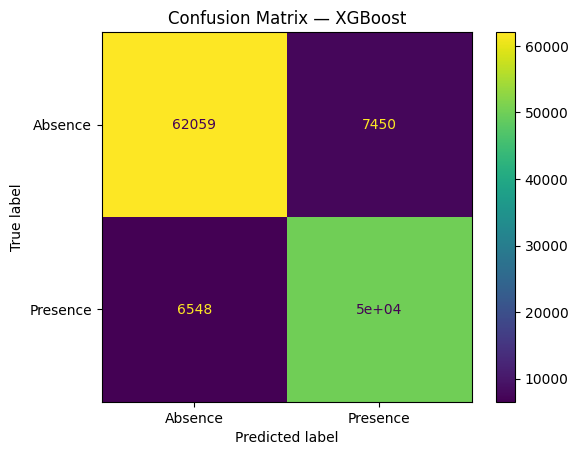

In [30]:
!pip install xgboost -q
from xgboost import XGBClassifier

scale = (y_train == 0).sum() / (y_train == 1).sum()

start = time.time()

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

train_time = time.time() - start
all_results.append(evaluate_model("XGBoost", xgb, X_val, y_val, train_time))
     


In [31]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df
     

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time(s)
0,XGBoost,0.8889,0.8702,0.8841,0.8771,0.9558,3.91
1,AdaBoost,0.8878,0.8856,0.8609,0.8730,0.9544,58.72
2,Bagging,0.8849,0.8817,0.8585,0.8700,0.9513,75.79


In [32]:
pred_proba = xgb.predict_proba(X_test_final)[:, 1]
pred_proba[:5]

array([0.9518532 , 0.00932854, 0.98516417, 0.00605298, 0.22320297],
      dtype=float32)

In [34]:

submission = pd.DataFrame({
    "id": test["id"],
    "Heart Disease": pred_proba
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,Heart Disease
0,630000,0.951853
1,630001,0.009329
2,630002,0.985164
3,630003,0.006053
4,630004,0.223203


In [35]:

!kaggle competitions submit -c playground-series-s6e2 -f submission.csv -m "XGBoost baseline"

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/urllib3/util/connection.py", line 60, in create_connection
    for res in socket.getaddrinfo(host, port, family, socket.SOCK_STREAM):
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 978, in getaddrinfo
    for res in _socket.getaddrinfo(host, port, family, type, proto, flags):
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
socket.gaierror: [Errno -3] Temporary failure in name resolution

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
             